In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"..\data\raw\GiveMeSomeCredit-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [6]:
df.shape

(150000, 12)

In [7]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column' : missing_percentage.index,
    'Missing Percentage' : missing_percentage.values
})
missing_df = missing_df.sort_values(by='Missing Percentage', ascending=False).reset_index(drop=True)

print(missing_df)

                                  Column  Missing Percentage
0                          MonthlyIncome           19.820667
1                     NumberOfDependents            2.616000
2                             Unnamed: 0            0.000000
3                       SeriousDlqin2yrs            0.000000
4                                    age            0.000000
5   RevolvingUtilizationOfUnsecuredLines            0.000000
6                              DebtRatio            0.000000
7   NumberOfTime30-59DaysPastDueNotWorse            0.000000
8        NumberOfOpenCreditLinesAndLoans            0.000000
9                NumberOfTimes90DaysLate            0.000000
10          NumberRealEstateLoansOrLines            0.000000
11  NumberOfTime60-89DaysPastDueNotWorse            0.000000


In [13]:
from sklearn.impute import SimpleImputer
import numpy as np

mode_imputer =  SimpleImputer(strategy='most_frequent')
df['NumberOfDependents'] = mode_imputer.fit_transform(df[['NumberOfDependents']])

df['MonthlyIncome_isMissing'] = np.where(df['MonthlyIncome'].isnull(), 1, 0)
median_imputer = SimpleImputer(strategy='median')

df['MonthlyIncome'] = median_imputer.fit_transform(df[['MonthlyIncome']])

In [14]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_isMissing
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0


In [15]:
df['MonthlyIncome_isMissing'].value_counts()

MonthlyIncome_isMissing
0    120269
1     29731
Name: count, dtype: int64

Counts:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
Ratio (1 vs 0): 0.07


C:\temp_tmp\ipykernel_8424\1333932338.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


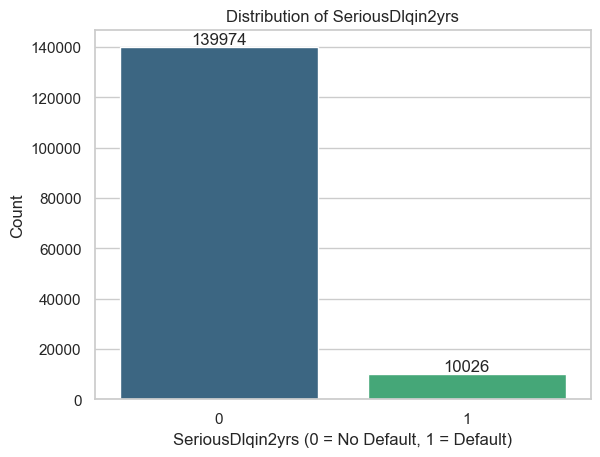

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
counts = df['SeriousDlqin2yrs'].value_counts().sort_index()
ratio = counts[1] / counts[0] if counts[0] != 0 else float('inf')

print("Counts:")
print(counts)
print(f"Ratio (1 vs 0): {ratio:.2f}")

# --- 2. Plot bar chart ---
sns.set(style="whitegrid")
ax = sns.barplot(
    x=counts.index.astype(str),  # Convert to string for better labels
    y=counts.values,
    palette="viridis"
)

ax.set_xlabel("SeriousDlqin2yrs (0 = No Default, 1 = Default)")
ax.set_ylabel("Count")
ax.set_title("Distribution of SeriousDlqin2yrs")

# Annotate bars with counts
for i, val in enumerate(counts.values):
    ax.text(i, val + 0.1, str(val), ha='center', va='bottom')

plt.show()

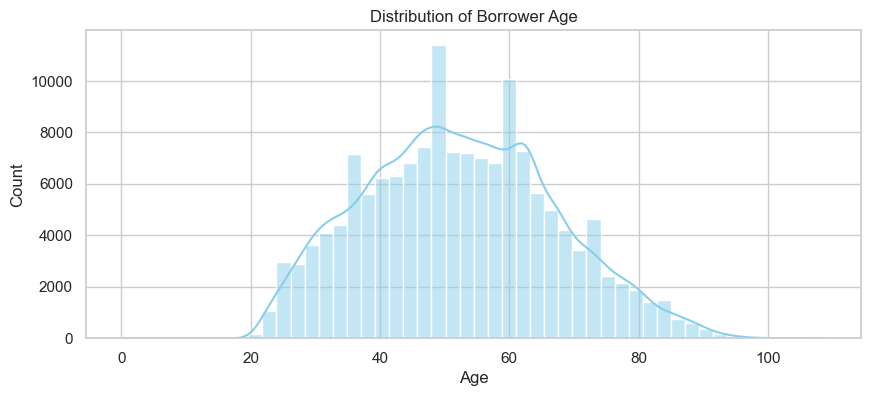

In [20]:
plt.figure(figsize=(10, 4))
sns.histplot(df['age'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Borrower Age')
plt.xlabel('Age')
plt.show()

In [21]:
underage_borrowers = df[df['age'] < 18]
print(f"Number of borrowers under 18: {len(underage_borrowers)}")
print(underage_borrowers[['age', 'SeriousDlqin2yrs', 'MonthlyIncome']])

Number of borrowers under 18: 1
       age  SeriousDlqin2yrs  MonthlyIncome
65695    0                 0         6000.0


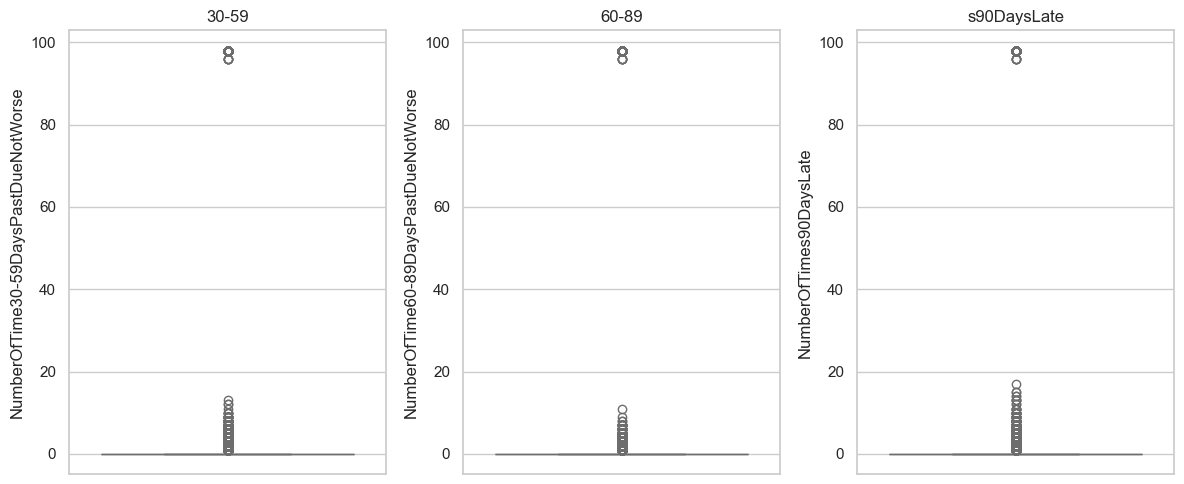

In [22]:
late_columns = [
    'NumberOfTime30-59DaysPastDueNotWorse', 
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

plt.figure(figsize=(12, 5))
for i, col in enumerate(late_columns):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(col.replace('NumberOfTime', '').replace('DaysPastDueNotWorse', ''))
plt.tight_layout()
plt.show()

In [23]:
print("Count of people with 96 or 98 past due:")
for col in late_columns:
    count_96_98 = len(df[df[col].isin([96, 98])])
    print(f"{col}: {count_96_98}")

Count of people with 96 or 98 past due:
NumberOfTime30-59DaysPastDueNotWorse: 269
NumberOfTime60-89DaysPastDueNotWorse: 269
NumberOfTimes90DaysLate: 269


In [24]:
# Look at the 99th percentile and the absolute maximum
print("99th percentile of Utilization:", df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99))
print("Maximum Utilization:", df['RevolvingUtilizationOfUnsecuredLines'].max())

# How many are over 1.0?
over_maxed = df[df['RevolvingUtilizationOfUnsecuredLines'] > 1]
print(f"\nBorrowers with > 100% utilization: {len(over_maxed)}")

# Let's see the really crazy ones (> 10x their limit)
insane_utilization = df[df['RevolvingUtilizationOfUnsecuredLines'] > 10]
print(f"Borrowers with > 1000% utilization: {len(insane_utilization)}")

99th percentile of Utilization: 1.0929557681400022
Maximum Utilization: 50708.0

Borrowers with > 100% utilization: 3321
Borrowers with > 1000% utilization: 241


In [25]:
# Check how Debt Ratio behaves when Monthly Income is missing vs present
missing_income_dr = df[df['MonthlyIncome'].isnull()]['DebtRatio']
present_income_dr = df[df['MonthlyIncome'].notnull()]['DebtRatio']

print("--- Median Debt Ratio ---")
print(f"When Income is known:   {present_income_dr.median():.2f}")
print(f"When Income is missing: {missing_income_dr.median():.2f}")

print("\n--- Max Debt Ratio ---")
print(f"When Income is missing: {missing_income_dr.max()}")

--- Median Debt Ratio ---
When Income is known:   0.37
When Income is missing: nan

--- Max Debt Ratio ---
When Income is missing: nan
